# Neural Network Approach

Now we will build a neural network taking a character and predicting the next character (same as bigram model but with learned weights). 

## Building the Dataset

In [1]:
import os

fpath = os.path.join('..', 'names.txt')
words = open(fpath, 'r').read().splitlines()

In [2]:
import torch

SE_TOKEN = '.'

chars = sorted(list(set(''.join(words)))) 
stoi = {s: i for i, s in enumerate(chars, start=1)}
stoi[SE_TOKEN] = 0
itos = {i: s for s, i in stoi.items()}

# Create the training set of bigrams
xs, ys = [], []

for w in words[:1]:
    chs = [SE_TOKEN] + list(w) + [SE_TOKEN]
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs)
print(ys)
print(xs.dtype)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])
torch.int64


In [3]:
# Convert the input into one-hot encoding
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
print(xenc.shape)
print(xenc.dtype)
print(xenc)

torch.Size([5, 27])
torch.float32
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])


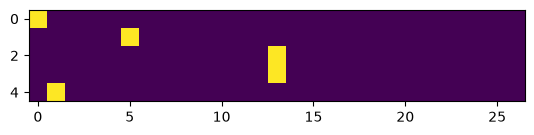

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(xenc)

In [5]:
# Our neural network will consist of a single layer
# Let's create 27 neurons with randomly initialized weights
W = torch.randn(27, 27)
print(xenc @ W)

# (5, 27) @ (27, 27) --> (5, 27)
print((xenc @ W)[0, 1])
print((xenc[0] * W[:, 1]).sum())

tensor([[-0.3420,  0.8196, -0.7063, -1.5663, -0.3033,  0.2558,  1.8882,  0.2648,
         -1.1439, -0.6488,  0.1041,  0.6875,  2.8014, -0.4296,  0.1353, -1.6013,
         -1.3362,  0.1735, -0.1767,  0.4354, -0.4651, -1.3075,  0.1125,  1.1571,
         -0.4868, -0.3367, -1.2511],
        [-0.2520,  2.0435, -0.8850, -0.8280, -0.6773, -0.3817,  0.2713, -1.3112,
          0.3900,  0.8043,  0.0393,  0.3542,  0.0186, -0.5149,  0.8887,  0.5262,
         -1.3909, -0.2552,  1.0833,  0.3515, -0.3413, -1.8992,  1.3564, -1.2409,
          0.1516, -0.7982, -0.4276],
        [-0.9003, -0.7273,  2.6394, -0.0664,  0.6576, -0.0156, -1.3750,  0.9087,
         -0.8757,  0.4128, -1.7082,  0.3980,  0.0391, -0.7184,  0.3090, -0.6350,
          2.1264, -0.0309,  1.5553, -1.4702,  1.2947, -1.0916, -1.4478, -0.5249,
          0.8532,  0.9267, -0.2331],
        [-0.9003, -0.7273,  2.6394, -0.0664,  0.6576, -0.0156, -1.3750,  0.9087,
         -0.8757,  0.4128, -1.7082,  0.3980,  0.0391, -0.7184,  0.3090, -0.6350

## Optimization 

In [6]:
# Randomly initialize 27 neurons' weights. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator=g)

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W # predict log-counts
counts = logits.exp() # equivalent to counts
probs = counts / counts.sum(1, keepdim=True) # probabilities for next charachter
# the last two lines here are together called a 'softmax'

In [7]:
# Let's see what the neural network initially assigns to correct labels
# We want to maximize those probabilities
print(ys)

print(probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0])
print(probs[torch.arange(ys.shape[0]), ys])

tensor([ 5, 13, 13,  1,  0])
tensor(0.0277) tensor(0.0163) tensor(0.0091) tensor(0.0091) tensor(0.0067)
tensor([0.0277, 0.0163, 0.0091, 0.0091, 0.0067])


In [8]:
# average negative log-likelihood
loss = - probs[torch.arange(ys.shape[0]), ys].log().mean()
loss.item()

4.421823501586914

In [16]:
# Now iterate over all the words
chars = sorted(list(set(''.join(words)))) 
stoi = {s: i for i, s in enumerate(chars, start=1)}
stoi[SE_TOKEN] = 0
itos = {i: s for s, i in stoi.items()}

# Create the training set of bigrams
xs, ys = [], []

for w in words:
    chs = [SE_TOKEN] + list(w) + [SE_TOKEN]
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print('number of examples', xs.nelement())
print(xs.shape)
print(ys.shape)

number of examples 228146
torch.Size([228146])
torch.Size([228146])


In [22]:
# Randomly initialize 27 neurons' weights. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [23]:
# gradient descent
for k in range(100):
    # Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # equivalent to counts
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next charachter
    loss = -probs[torch.arange(ys.shape[0]), ys].log().mean() + 0.01 * (W**2).mean()
    print(f'{k:2d}, {loss.item():.4f}')

    # backward pass
    W.grad = None # same effect as setting to 0.0 but more efficient in pytorch
    loss.backward()

    # update
    W.data -= 50.0 * W.grad

 0, 3.7686
 1, 3.3788
 2, 3.1611
 3, 3.0272
 4, 2.9345
 5, 2.8672
 6, 2.8167
 7, 2.7771
 8, 2.7453
 9, 2.7188
10, 2.6965
11, 2.6774
12, 2.6608
13, 2.6464
14, 2.6337
15, 2.6225
16, 2.6125
17, 2.6037
18, 2.5958
19, 2.5887
20, 2.5823
21, 2.5764
22, 2.5711
23, 2.5663
24, 2.5618
25, 2.5577
26, 2.5539
27, 2.5504
28, 2.5472
29, 2.5442
30, 2.5414
31, 2.5387
32, 2.5363
33, 2.5340
34, 2.5318
35, 2.5298
36, 2.5279
37, 2.5261
38, 2.5244
39, 2.5228
40, 2.5213
41, 2.5198
42, 2.5185
43, 2.5172
44, 2.5160
45, 2.5148
46, 2.5137
47, 2.5127
48, 2.5117
49, 2.5108
50, 2.5099
51, 2.5090
52, 2.5082
53, 2.5074
54, 2.5066
55, 2.5059
56, 2.5052
57, 2.5045
58, 2.5039
59, 2.5033
60, 2.5027
61, 2.5021
62, 2.5016
63, 2.5011
64, 2.5006
65, 2.5001
66, 2.4996
67, 2.4992
68, 2.4987
69, 2.4983
70, 2.4979
71, 2.4975
72, 2.4971
73, 2.4967
74, 2.4964
75, 2.4960
76, 2.4957
77, 2.4954
78, 2.4950
79, 2.4947
80, 2.4944
81, 2.4941
82, 2.4939
83, 2.4936
84, 2.4933
85, 2.4931
86, 2.4928
87, 2.4926
88, 2.4923
89, 2.4921
90, 2.4919

The expected negative log likelihood (NLL) loss should be around the NLL of bigram model which was 2.4241 (without smoothing).

Instead of counting explicitly which is the case in bigram model, we learn the appropriate weights with a gradient-based algorithm (gradient-descent) in a very simple single layer neural network.

The gradient-based approach is significantly more flexiable and can be scale easly. For instance instead of feeding a single input character, we can feed a sequence of characters and predict the next character based on this sequence. This doesn't requires any change the gradient-based optimization. Because the output of the neural network is just logits. We will pass through softmax, calculate the loss function (NLL), and do gradient-based optimisation. 

Regardless of the network complexity (up to transformer), the optimisation process is same. The only change is in the way forward pass done, the calculation of the logits.

As we increase the smoothing value (+1 to +1000), the probabilities in the bigram table will become a uniform distribution. The uniform distribution can be obtained by setting all the weights to be zero (exp(0) = 1 and when you add them up and divide, you get uniform distribution). So we can add a regularization term like smoothing, and its effect will be same as the smoothing value. Adding more counts to bigram table is equvalent to increasing the regularization term weight. This term is necessary, because we want to have the probabilities to be uniform except for the correct class.

In [30]:
# Finally, sample from the neural net model
# Randomly initialize 27 neurons' weights. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
SE_IX = stoi[SE_TOKEN]

for i in range(10):
    out = []
    ix = SE_IX

    while True:
        xenc = F.one_hot(torch.tensor([ix]), 27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts
        p = counts / counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
        out.append(itos[ix])

        if ix == SE_IX:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


If you compare the outputs of the bigram model and neural network, they are identical! Because we embed the probability distributions of the bigram counts into neural network weights.